<a href="https://colab.research.google.com/github/pmoorti/CRES-Waterfront-Research/blob/main/CRES_Waterfront_Research_highbridge_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data loading

### Subtask:
Load the CSV files into pandas DataFrames.
Clean each dataset (drop na values, rename columns etc.)


In [ ]:
import pandas as pd

df_hospitalizations = pd.read_csv('Asthma Hospitalizations.csv')
df_hospitalizations_cleaned = df_hospitalizations.dropna(how='all')
df_hospitalizations_cleaned = df_hospitalizations_cleaned.rename(columns={
    'Unnamed: 0': 'Location',
    'Unnamed: 1': 'Age Group',
    'Unnamed: 2': 'Year',
    'Unnamed: 3': 'Data Format',
    'Unnamed: 4': 'Data',
    'Unnamed: 5': 'Fips'}) #The "Fips" column in your datasets refers to a geographic identifier code. FIPS (Federal Information Processing Standards) codes are standardized numeric or alphanumeric codes assigned to geographic areas.

df_hospitalizations_cleaned = df_hospitalizations_cleaned.drop(index=4)
df_hospitalizations_cleaned.to_csv('cleaned_hospitalizations.csv', index=False)
display(df_hospitalizations_cleaned.head())


,Location,Age Group,Year,Data Format,Data,Fips
5,Bayside - Little Neck,0 to 4 years,2000,Number,19,uhf404
6,Bayside - Little Neck,0 to 4 years,2000,Rate,43.8,uhf404
7,Bedford Stuyvesant - Crown Heights,0 to 4 years,2000,Number,485,uhf203
8,Bedford Stuyvesant - Crown Heights,0 to 4 years,2000,Rate,192.6,uhf203
9,Bensonhurst - Bay Ridge,0 to 4 years,2000,Number,17,uhf209


In [ ]:
df_incomes= pd.read_csv('Median Incomes.csv')
df_incomes.head()

df_incomes_cleaned = df_incomes.dropna(how='all')
df_incomes_cleaned = df_incomes_cleaned.rename(columns={
    'Unnamed: 0': 'Location',
    'Unnamed: 1': 'Household Type',
    'Unnamed: 2': 'Timeframe',
    'Unnamed: 3': 'Data Format',
    'Unnamed: 4': 'Data',
    'Unnamed: 5': 'Fips'})
df_incomes_cleaned = df_incomes_cleaned.drop(index=4)
display(df_incomes_cleaned.head())
df_incomes_cleaned.to_csv('cleaned_incomes.csv', index=False)



,Location,Household Type,Timeframe,Data Format,Data,Fips
5,Astoria,All Households,2023,Dollars,84590,401
6,Astoria,Families,2023,Dollars,94918,401
7,Astoria,Families with Children,2023,Dollars,85568,401
8,Astoria,Families without Children,2023,Dollars,110222,401
9,Battery Park/Tribeca,All Households,2023,Dollars,198945,101


In [ ]:
city_wide_df = pd.read_csv('/content/NYC Asthma hospitalizations (age 5 to 17) (full table).csv')
city_wide_df.head()

,TimePeriod,GeoType,GeoID,GeoRank,Geography,"Estimated annual rate per 10,000",Number
0,2020,CD,102,6,Greenwich Village and Soho (CD2),1.8*,1*
1,2020,CD,103,6,Lower East Side and Chinatown (CD3),3.6*,6*
2,2020,CD,104,6,Clinton and Chelsea (CD4),7.4*,6*
3,2020,CD,106,6,Stuyvesant Town and Turtle Bay (CD6),6.8*,5*
4,2020,CD,107,6,Upper West Side (CD7),3.2*,7*


In [ ]:
poverty_df = pd.read_csv('/content/Poverty by Race_Ethnicity.csv')
poverty_df.head()

poverty_df_cleaned = poverty_df.dropna(how='all')
poverty_df_cleaned = poverty_df_cleaned.rename(columns={
    'Unnamed: 0': 'Location',
    'Unnamed: 1': 'Race/ Ethnicity',
    'Unnamed: 2': 'Year',
    'Unnamed: 3': 'Data Format',
    'Unnamed: 4': 'Data',
    'Unnamed: 5': 'Fips'})


poverty_df_cleaned = poverty_df_cleaned.drop(index=4)
poverty_df_cleaned.to_csv('cleaned_poverty.csv', index=False)
display(poverty_df_cleaned.head())


,Location,Race/ Ethnicity,Year,Data Format,Data,Fips
5,Tottenville,Latino,2012,Percent,0.0097,503
6,Battery Park/Tribeca,Black,2012,Percent,0.01446,101
7,Greenwich Village,Black,2012,Percent,0.01446,102
8,Upper East Side,Asian,2011,Percent,0.0145,108
9,University Heights,Asian,2011,Percent,0.01764,205


# **Multiple Linear Regression**

Independent Varibles
*   Median Income
*   Poverty
*   Location

Dependent Variable
*   Asthma Hospitalizations


- Comparing Motthaven/Highbridge to city wide stats
- Comapring Pelham to city wide stats







In [ ]:
df_hospitalizations_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3263 entries, 5 to 3267
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Location     3263 non-null   object
 1   Age Group    3263 non-null   object
 2   Year         3263 non-null   object
 3   Data Format  3263 non-null   object
 4   Data         3263 non-null   object
 5   Fips         3263 non-null   object
dtypes: object(6)
memory usage: 178.4+ KB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set the plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
sns.set_context("talk")

# Load the cleaned asthma hospitalizations data for Highbridge
def load_cleaned_asthma_data(file_path='cleaned_hospitalizations.csv'):
    """Load and prepare cleaned asthma hospitalization data"""
    asthma_df = pd.read_csv(file_path)

    # Filter for Rate data format
    asthma_df = asthma_df[asthma_df['Data Format'] == 'Rate']

    # Rename columns for clarity
    asthma_df = asthma_df.rename(columns={'Data': 'Rate'})

    # Ensure Rate is numeric
    asthma_df['Rate'] = pd.to_numeric(asthma_df['Rate'], errors='coerce')

    return asthma_df

# Load the NYC EH Data Portal data for NYC stats
def load_nyc_data(file_path='/content/NYC Asthma hospitalizations (age 5 to 17) (full table).csv'):
    """Load and prepare NYC Data Portal asthma data for citywide statistics"""
    asthma_df = pd.read_csv(file_path)

    # Clean up column names
    asthma_df.columns = asthma_df.columns.str.strip()

   # Convert rate column to numeric, handling asterisks and empty strings
    asthma_df['Rate'] = pd.to_numeric(asthma_df['Estimated annual rate per 10,000'].str.replace('*', ''), errors='coerce')
    asthma_df['Rate'] = asthma_df['Rate'].fillna(0) # replace NaN with 0 for analysis. 0 will show as a normal part of a graph/regression analysis. If you want to avoid affecting statistical analysis, then replacing with mean would be better.
    return asthma_df


In [ ]:
# Filter for NYC data in the NYC Data Portal dataset
def filter_nyc_data(df):
    """Filter NYC Data Portal dataframe for NYC citywide data"""
    # Create a new area column
    df['Area'] = 'Other'

    # Map NYC
    nyc_patterns = ['New York City', 'NYC', 'Citywide']
    for pattern in nyc_patterns:
        mask = df['Geography'].str.contains(pattern, case=False, na=False)
        df.loc[mask, 'Area'] = 'NYC'

    # Filter to only NYC
    df_filtered = df[df['Area'] == 'NYC'].copy()

    # Rename TimePeriod to Year for consistency
    df_filtered = df_filtered.rename(columns={'TimePeriod': 'Year'})

    return df_filtered

In [ ]:
# Filter for Highbridge data in the cleaned dataset
def filter_highbridge_data(df, age_group='5 to 17 Years'):
    """Filter cleaned dataframe for Highbridge data and specified age group"""
    # Create a new area column
    df['Area'] = 'Other'

    # Map Highbridge
    highbridge_patterns = ['Concourse/Highbridge', 'Highbridge - Concourse', 'High Bridge']
    for pattern in highbridge_patterns:
        mask = df['Location'].str.contains(pattern, case=False, na=False)
        df.loc[mask, 'Area'] = 'Highbridge'

    # Filter to only Highbridge and the specified age group
    df_filtered = df[(df['Area'] == 'Highbridge') &
                     (df['Age Group'] == age_group)].copy()

    return df_filtered

In [ ]:
# Combine Highbridge and NYC data for comparison
def combine_data(highbridge_df, nyc_df):
    """Combine Highbridge and NYC data from different sources"""
    # Select only needed columns
    highbridge_data = highbridge_df[['Year', 'Area', 'Rate']].copy()
    nyc_data = nyc_df[['Year', 'Area', 'Rate']].copy()

    # Combine the datasets
    combined_df = pd.concat([highbridge_data, nyc_data])

    return combined_df

In [ ]:

# Compare Highbridge to NYC rates over time
def compare_highbridge_nyc(combined_df):
    """Compare Highbridge to NYC asthma hospitalization rates over time"""
    # Group by year and area, get mean rate
    yearly_rates = combined_df.groupby(['Year', 'Area'])['Rate'].mean().reset_index()

    # Pivot to get areas as columns
    rate_comparison = yearly_rates.pivot(index='Year', columns='Area', values='Rate')

    # Calculate ratio of Highbridge to NYC
    rate_comparison['Highbridge_to_NYC_Ratio'] = rate_comparison['Highbridge'] / rate_comparison['NYC']

    # Calculate difference between Highbridge and NYC
    rate_comparison['Highbridge_minus_NYC'] = rate_comparison['Highbridge'] - rate_comparison['NYC']

    return rate_comparison

In [ ]:
# Plot the comparison
def plot_comparison(rate_comparison):
    """Plot the comparison between Highbridge and NYC rates"""
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot rates on the first subplot
    rate_comparison[['Highbridge', 'NYC']].plot(
        ax=ax1, marker='o', linewidth=2,
        color=['#ff7f0e', '#1f77b4']
    )

    ax1.set_title('Asthma Hospitalization Rates: Highbridge vs NYC (Ages 5-17)', fontsize=16)
    ax1.set_ylabel('Rate per 10,000 Children', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)

    # Highlight the difference
    for idx, row in rate_comparison.iterrows():
        if not pd.isna(row['Highbridge']) and not pd.isna(row['NYC']):
            # Draw a line between the two points
            ax1.plot([idx, idx], [row['NYC'], row['Highbridge']],
                     'k-', alpha=0.3)

    # Plot ratio on the second subplot
    rate_comparison['Highbridge_to_NYC_Ratio'].plot(
        ax=ax2, marker='s', linewidth=2, color='darkred'
    )

    # Add a reference line at ratio=1
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7)

    ax2.set_title('Ratio of Highbridge to NYC Asthma Hospitalization Rates', fontsize=16)
    ax2.set_ylabel('Ratio (Highbridge/NYC)', fontsize=14)
    ax2.set_xlabel('Year', fontsize=14)
    ax2.grid(True, alpha=0.3)

    # Format y-axis to show as multiplier
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    return fig


In [ ]:
# Calculate summary statistics
def calculate_statistics(rate_comparison):
    """Calculate summary statistics for the comparison"""
    # Average rates
    avg_highbridge = rate_comparison['Highbridge'].mean()
    avg_nyc = rate_comparison['NYC'].mean()

    # Average ratio
    avg_ratio = rate_comparison['Highbridge_to_NYC_Ratio'].mean()

    # T-test for difference
    highbridge_rates = rate_comparison['Highbridge'].dropna()
    nyc_rates = rate_comparison['NYC'].dropna()

    # Only perform t-test if enough data
    if len(highbridge_rates) > 1 and len(nyc_rates) > 1:
        t_stat, p_value = stats.ttest_ind(highbridge_rates, nyc_rates, equal_var=False) #Using stats from scipy module that was imported
    else:
        t_stat, p_value = np.nan, np.nan

    # Percent higher
    pct_higher = (avg_highbridge / avg_nyc - 1) * 100

    # Create a summary dataframe
    stats_df = pd.DataFrame({
        'Statistic': ['Average Rate (Highbridge)', 'Average Rate (NYC)',
                     'Average Ratio (Highbridge/NYC)', 'Percent Higher',
                     'T-statistic', 'P-value'],
        'Value': [avg_highbridge, avg_nyc, avg_ratio,
                 pct_higher, t_stat, p_value]
    })

    return stats_df


Common years in both datasets: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]

Asthma Hospitalization Rates (per 10,000 children aged 5-17):
Area  Highbridge   NYC  Highbridge_to_NYC_Ratio  Highbridge_minus_NYC
Year                                                                 
2005        61.1  35.9                      1.7                  25.2
2006        57.6  35.4                      1.6                  22.2
2007        51.2  33.1                      1.5                  18.1
2008        53.7  31.1                      1.7                  22.6
2009        60.2  33.2                      1.8                  27.0
2010        43.7  28.3                      1.5                  15.4
2011        57.0  29.5                      1.9                  27.5
2012        62.5  32.0                      2.0                  30.5
2013        6

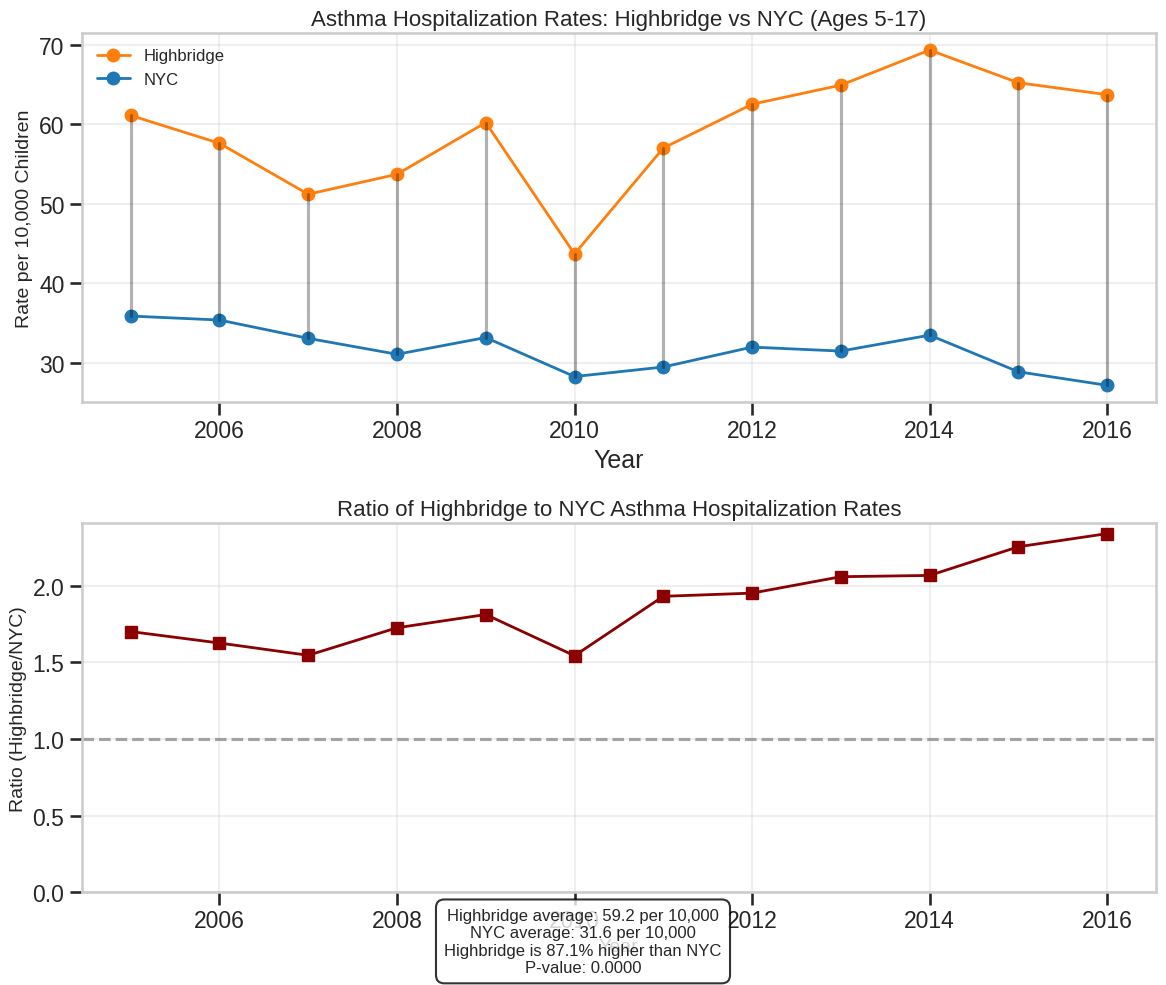

In [ ]:
# Main function to execute the analysis
def main():
    """Main function to execute the Highbridge vs NYC comparison"""
    # Load datasets
    cleaned_asthma_df = load_cleaned_asthma_data()
    nyc_asthma_df = load_nyc_data()

    # Filter each dataset for the data we need
    highbridge_data = filter_highbridge_data(cleaned_asthma_df)
    nyc_data = filter_nyc_data(nyc_asthma_df)

    # Combine the datasets
    combined_data = combine_data(highbridge_data, nyc_data)

    # Get years that exist in both datasets
    highbridge_years = set(highbridge_data['Year'].unique())
    nyc_years = set(nyc_data['Year'].unique())
    common_years = highbridge_years.intersection(nyc_years)

    print(f"Common years in both datasets: {sorted(common_years)}")

    # Filter to common years
    combined_data_common_years = combined_data[combined_data['Year'].isin(common_years)]

    # Compare rates over time
    rate_comparison = compare_highbridge_nyc(combined_data_common_years)

    # Print the comparison table
    print("\nAsthma Hospitalization Rates (per 10,000 children aged 5-17):")
    print(rate_comparison.round(1))

    # Calculate statistics
    stats = calculate_statistics(rate_comparison)
    print("\nSummary Statistics:")
    print(stats)

    # Create visualization
    fig = plot_comparison(rate_comparison)

    # Add text summary to the plot
    text_summary = (
        f"Highbridge average: {stats.loc[0, 'Value']:.1f} per 10,000\n"
        f"NYC average: {stats.loc[1, 'Value']:.1f} per 10,000\n"
        f"Highbridge is {stats.loc[3, 'Value']:.1f}% higher than NYC\n"
        f"P-value: {stats.loc[5, 'Value']:.4f}"
    )

    plt.figtext(0.5, 0.01, text_summary, ha='center', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

    plt.savefig('highbridge_vs_nyc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return rate_comparison, stats, combined_data_common_years

# Execute the analysis
if __name__ == "__main__":
    rate_comparison, stats, combined_data = main()

Years with data from all three sources: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2016]

Highbridge Data Across Years:
 Year  Median_Income  Asthma_Rate  Poverty_Rate
 2007    35214.89540         51.2        39.532
 2008    33826.02770         53.7        37.864
 2009    40042.91396         60.2        35.986
 2010    35735.22211         43.7        34.037
 2011    29700.43478         57.0        40.232
 2012    34362.10782         62.5        36.090
 2013    33082.04641         64.9        39.417
 2014    33659.88392         69.3        37.388
 2016    38511.62835         63.7        36.000


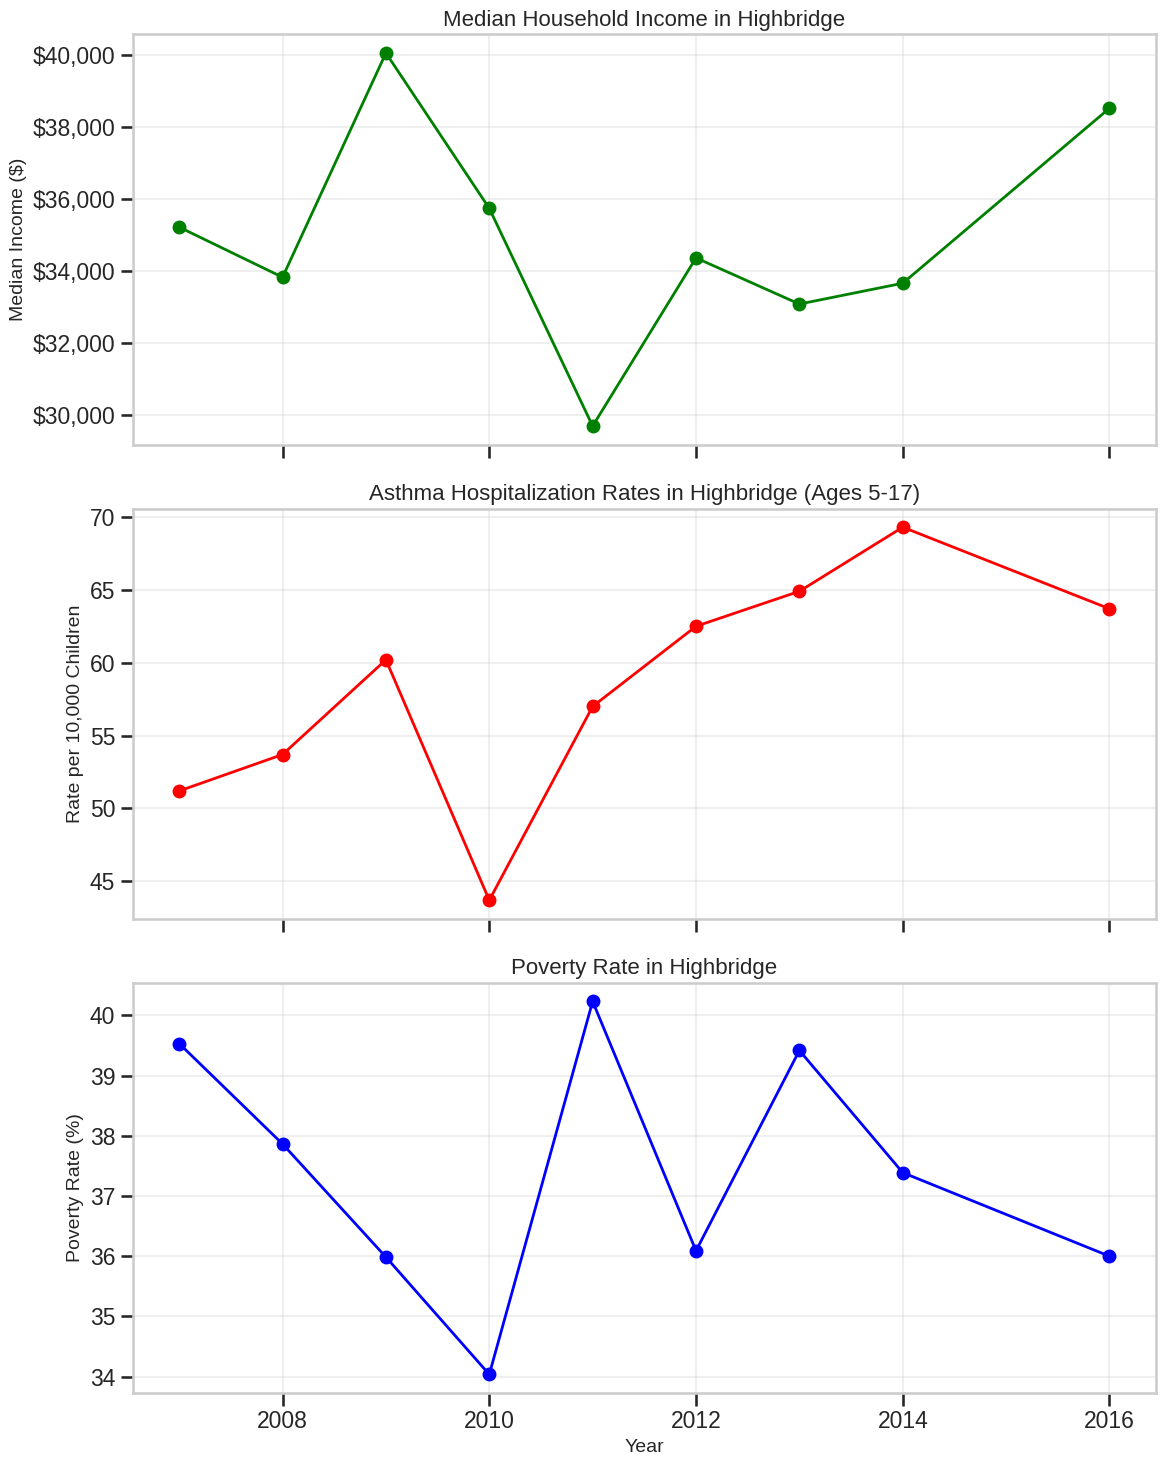


Correlation Matrix:
               Median_Income  Asthma_Rate  Poverty_Rate
Median_Income       1.000000    -0.007085     -0.653962
Asthma_Rate        -0.007085     1.000000      0.196501
Poverty_Rate       -0.653962     0.196501      1.000000


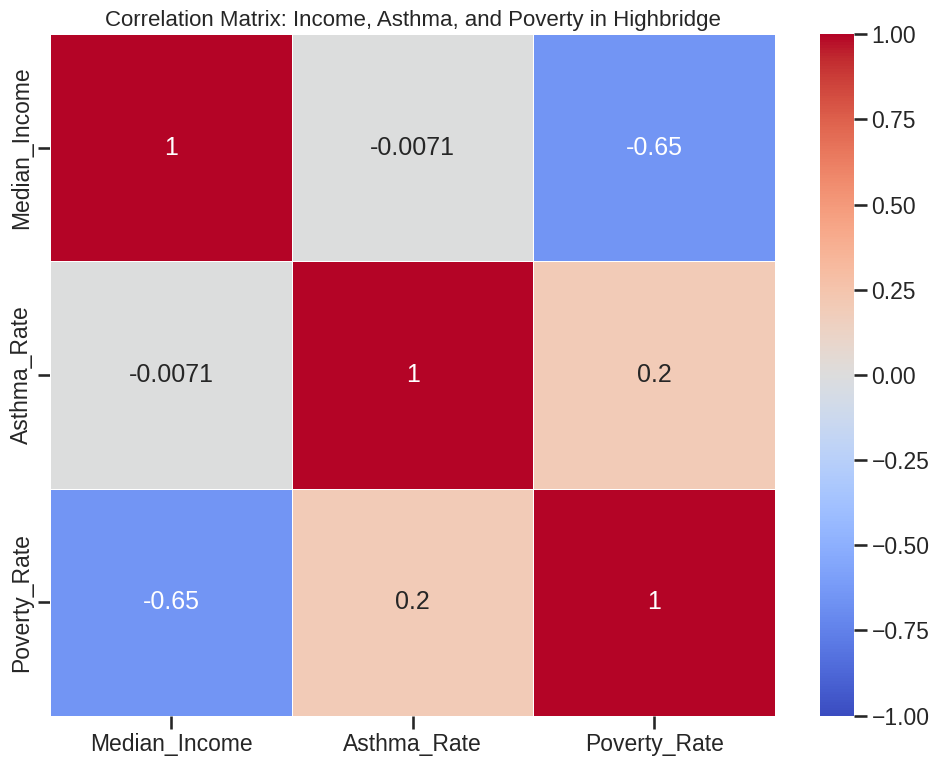

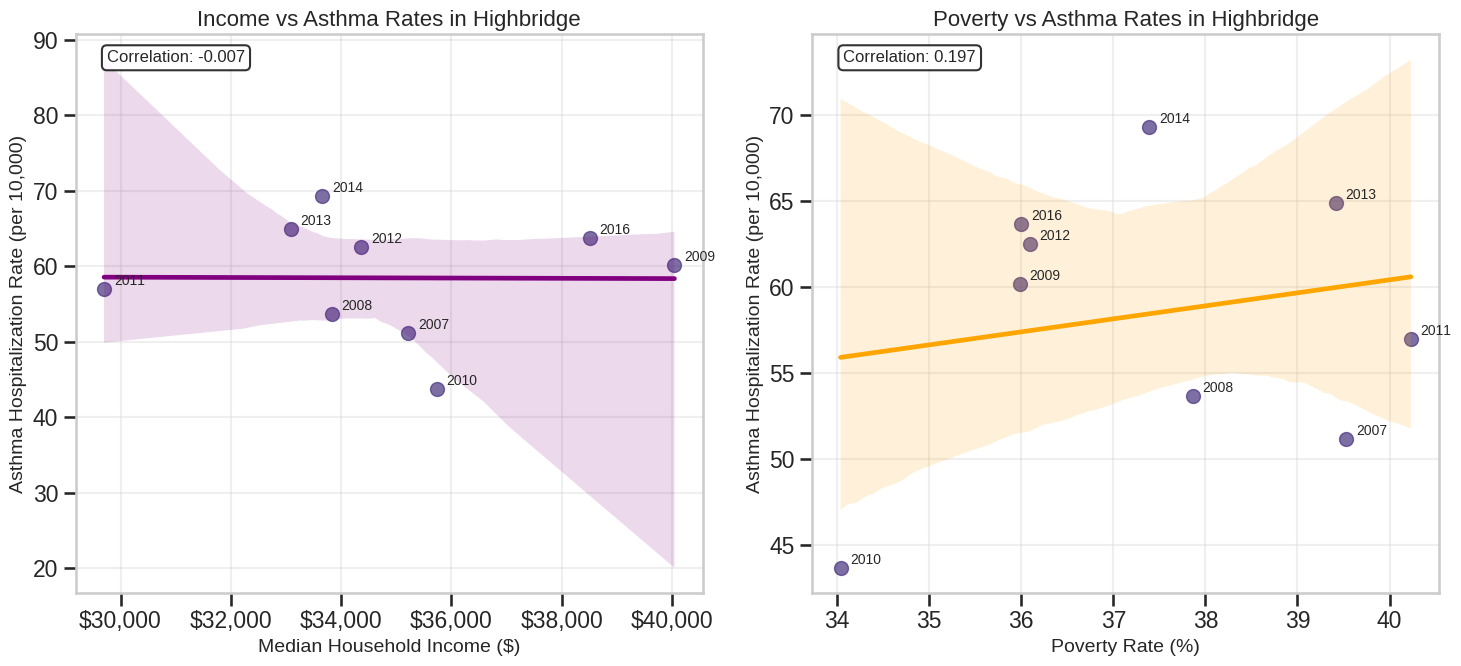


Running regression analysis...

Regression Results:
                            OLS Regression Results                            
Dep. Variable:            Asthma_Rate   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                 -0.248
Method:                 Least Squares   F-statistic:                    0.2064
Date:                Wed, 02 Apr 2025   Prob (F-statistic):              0.819
Time:                        04:29:37   Log-Likelihood:                -30.560
No. Observations:                   9   AIC:                             67.12
Df Residuals:                       6   BIC:                             67.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
def analyze_highbridge_trends(income_file='cleaned_incomes.csv',
                              asthma_file='cleaned_hospitalizations.csv',
                              poverty_file='cleaned_poverty.csv'):
    """
    Analyze the relationships between median income, poverty rates, and asthma
    hospitalization rates in Highbridge over time.

    Parameters:
    income_file (str): Path to the cleaned income CSV file
    asthma_file (str): Path to the cleaned asthma hospitalizations CSV file
    poverty_file (str): Path to the cleaned poverty CSV file

    Returns:
    tuple: (model, highbridge_data)
        - model: Statsmodels regression results object
        - highbridge_data: DataFrame with all Highbridge data across years
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    import statsmodels.api as sm
    import statsmodels.formula.api as smf

    # Load datasets
    income_df = pd.read_csv(income_file)
    asthma_df = pd.read_csv(asthma_file)
    poverty_df = pd.read_csv(poverty_file)

    # Filter for Highbridge data in each dataset
    # Income data for Highbridge, All Households
    highbridge_income = income_df[
        (income_df['Location'].str.contains('Concourse/Highbridge', case=False, na=False)) &
        (income_df['Household Type'] == 'All Households')
    ].copy()

    highbridge_income['Median_Income'] = pd.to_numeric(highbridge_income['Data'])
    highbridge_income = highbridge_income.rename(columns={'Timeframe': 'Year'})

    # Asthma data for Highbridge, 5-17 age group, Rate format
    highbridge_asthma = asthma_df[
        (asthma_df['Location'].str.contains('Concourse/Highbridge|High Bridge', case=False, na=False)) &
        (asthma_df['Age Group'] == '5 to 17 Years') &
        (asthma_df['Data Format'] == 'Rate')
    ].copy()

    highbridge_asthma['Asthma_Rate'] = pd.to_numeric(highbridge_asthma['Data'])

    # Poverty data for Highbridge, All Races and Ethnicities, Percent format
    highbridge_poverty = poverty_df[
        (poverty_df['Location'].str.contains('Concourse/Highbridge', case=False, na=False)) &
        (poverty_df['Race/ Ethnicity'] == 'All Races and Ethnicities') &
        (poverty_df['Data Format'] == 'Percent')
    ].copy()

    highbridge_poverty['Poverty_Rate'] = pd.to_numeric(highbridge_poverty['Data']) * 100  # Convert to percentage

    # Find common years across all datasets
    income_years = set(highbridge_income['Year'])
    asthma_years = set(highbridge_asthma['Year'])
    poverty_years = set(highbridge_poverty['Year'])

    common_years = income_years.intersection(asthma_years).intersection(poverty_years)
    print(f"Years with data from all three sources: {sorted(common_years)}")

    # Merge datasets for those years
    # First, filter each dataset to common years
    highbridge_income_filtered = highbridge_income[highbridge_income['Year'].isin(common_years)]
    highbridge_asthma_filtered = highbridge_asthma[highbridge_asthma['Year'].isin(common_years)]
    highbridge_poverty_filtered = highbridge_poverty[highbridge_poverty['Year'].isin(common_years)]

    # Create a base dataframe with years
    highbridge_data = pd.DataFrame({'Year': sorted(common_years)})

    # Add data from each source
    for year in sorted(common_years):
        # Income data
        year_income = highbridge_income_filtered[highbridge_income_filtered['Year'] == year]['Median_Income'].values
        if len(year_income) > 0:
            highbridge_data.loc[highbridge_data['Year'] == year, 'Median_Income'] = year_income[0]

        # Asthma data
        year_asthma = highbridge_asthma_filtered[highbridge_asthma_filtered['Year'] == year]['Asthma_Rate'].values
        if len(year_asthma) > 0:
            highbridge_data.loc[highbridge_data['Year'] == year, 'Asthma_Rate'] = year_asthma[0]

        # Poverty data
        year_poverty = highbridge_poverty_filtered[highbridge_poverty_filtered['Year'] == year]['Poverty_Rate'].values
        if len(year_poverty) > 0:
            highbridge_data.loc[highbridge_data['Year'] == year, 'Poverty_Rate'] = year_poverty[0]

    # Print the compiled data
    print("\nHighbridge Data Across Years:")
    print(highbridge_data.to_string(index=False))

    # Create time series plots
    fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

    # Plot 1: Median Income over time
    axes[0].plot(highbridge_data['Year'], highbridge_data['Median_Income'],
                marker='o', linestyle='-', color='green', linewidth=2)
    axes[0].set_title('Median Household Income in Highbridge', fontsize=16)
    axes[0].set_ylabel('Median Income ($)', fontsize=14)
    # Format y-axis as currency
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Asthma Rate over time
    axes[1].plot(highbridge_data['Year'], highbridge_data['Asthma_Rate'],
                marker='o', linestyle='-', color='red', linewidth=2)
    axes[1].set_title('Asthma Hospitalization Rates in Highbridge (Ages 5-17)', fontsize=16)
    axes[1].set_ylabel('Rate per 10,000 Children', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Poverty Rate over time
    axes[2].plot(highbridge_data['Year'], highbridge_data['Poverty_Rate'],
                marker='o', linestyle='-', color='blue', linewidth=2)
    axes[2].set_title('Poverty Rate in Highbridge', fontsize=16)
    axes[2].set_ylabel('Poverty Rate (%)', fontsize=14)
    axes[2].set_xlabel('Year', fontsize=14)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('highbridge_trends_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Create correlation matrix
    corr_matrix = highbridge_data[['Median_Income', 'Asthma_Rate', 'Poverty_Rate']].corr()
    print("\nCorrelation Matrix:")
    print(corr_matrix)

    # Create correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    plt.title('Correlation Matrix: Income, Asthma, and Poverty in Highbridge', fontsize=16)
    plt.tight_layout()
    plt.savefig('highbridge_correlation_heatmap.png', dpi=300)
    plt.show()

    # Create scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Plot 1: Income vs Asthma
    sns.regplot(x='Median_Income', y='Asthma_Rate', data=highbridge_data, ax=axes[0],
               scatter_kws={'s': 100, 'alpha': 0.7}, line_kws={'color': 'purple'})

    # Add year labels to points
    for i, row in highbridge_data.iterrows():
        axes[0].annotate(str(int(row['Year'])),
                        (row['Median_Income'], row['Asthma_Rate']),
                        xytext=(7, 3), textcoords='offset points',
                        fontsize=10)

    axes[0].set_title('Income vs Asthma Rates in Highbridge', fontsize=16)
    axes[0].set_xlabel('Median Household Income ($)', fontsize=14)
    axes[0].set_ylabel('Asthma Hospitalization Rate (per 10,000)', fontsize=14)
    # Format x-axis as currency
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
    axes[0].grid(True, alpha=0.3)

    # Calculate and add correlation info
    corr_income_asthma = corr_matrix.loc['Median_Income', 'Asthma_Rate']
    axes[0].annotate(f"Correlation: {corr_income_asthma:.3f}", xy=(0.05, 0.95),
                    xycoords='axes fraction', fontsize=12,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # Plot 2: Poverty vs Asthma
    sns.regplot(x='Poverty_Rate', y='Asthma_Rate', data=highbridge_data, ax=axes[1],
               scatter_kws={'s': 100, 'alpha': 0.7}, line_kws={'color': 'orange'})

    # Add year labels to points
    for i, row in highbridge_data.iterrows():
        axes[1].annotate(str(int(row['Year'])),
                        (row['Poverty_Rate'], row['Asthma_Rate']),
                        xytext=(7, 3), textcoords='offset points',
                        fontsize=10)

    axes[1].set_title('Poverty vs Asthma Rates in Highbridge', fontsize=16)
    axes[1].set_xlabel('Poverty Rate (%)', fontsize=14)
    axes[1].set_ylabel('Asthma Hospitalization Rate (per 10,000)', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Calculate and add correlation info
    corr_poverty_asthma = corr_matrix.loc['Poverty_Rate', 'Asthma_Rate']
    axes[1].annotate(f"Correlation: {corr_poverty_asthma:.3f}", xy=(0.05, 0.95),
                    xycoords='axes fraction', fontsize=12,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('highbridge_scatterplots.png', dpi=300)
    plt.show()

    # Run regression model (if we have enough data points)
    if len(highbridge_data) >= 5:
        print("\nRunning regression analysis...")
        formula = 'Asthma_Rate ~ Median_Income + Poverty_Rate'
        model = smf.ols(formula=formula, data=highbridge_data).fit()

        print("\nRegression Results:")
        print(model.summary())

        # Return the model and data
        return model, highbridge_data
    else:
        print("\nNot enough data points for regression analysis. Need at least 5 years of data.")
        return None, highbridge_data

# Run the analysis
model, highbridge_data = analyze_highbridge_trends()